
Summary Statistics (Disorder Probability):
Total residues compared: 577
Average disorder change: -0.466
Residues with increased disorder: 64
Residues with decreased disorder: 512


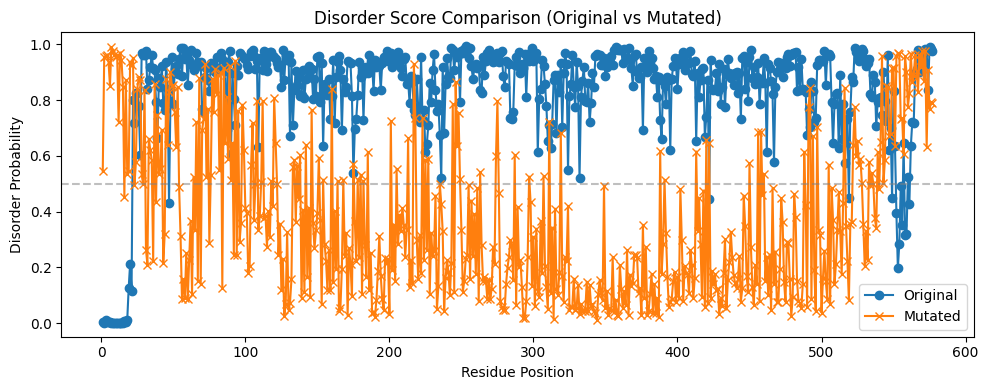


Summary Statistics (Disorder Labels):
Total residues:             577
Unchanged predictions:      202
Ordered → Disordered:       26
Disordered → Ordered:       349


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # === Function to load disorder prediction files ===
# def read_disorder_file(file_path):
#     disorder_data = []
#     with open(file_path, 'r') as f:
#         for line in f:
#             if line.startswith('>') or line.strip() == '':
#                 continue
#             parts = line.strip().split()
#             if len(parts) == 4:
#                 seq_no = int(parts[0])
#                 aa = parts[1]
#                 prob = float(parts[2])
#                 flag = int(parts[3])
#                 disorder_data.append([seq_no, aa, prob, flag])
#     df = pd.DataFrame(disorder_data, columns=['SeqNo', 'AA', 'DisorderProb', 'Disordered'])
#     return df


# # === Load files ===
# original_disorder_df = read_disorder_file("./Dispred/fonPB_O.dispred")
# mutated_disorder_df = read_disorder_file("./Dispred/fonPB_M.dispred")

# # === Merge for analysis ===
# comparison_df = pd.merge(original_disorder_df, mutated_disorder_df,
#                          on='SeqNo', suffixes=('_orig', '_mut'))

# # === Part 1: Compare Disorder Probabilities ===
# comparison_df['DeltaDisorder'] = comparison_df['DisorderProb_mut'] - comparison_df['DisorderProb_orig']

# # Summary statistics for disorder probabilities
# num_residues = len(comparison_df)
# avg_delta = comparison_df['DeltaDisorder'].mean()
# num_increased = (comparison_df['DeltaDisorder'] > 0).sum()
# num_decreased = (comparison_df['DeltaDisorder'] < 0).sum()

# # Output: Disorder probability comparison
# # print("\nDisorder Probability Comparison Per Residue:")
# # print(comparison_df[['SeqNo', 'AA_orig', 'AA_mut', 'DisorderProb_orig', 'DisorderProb_mut', 'DeltaDisorder']])

# print("\nSummary Statistics (Disorder Probability):")
# print(f"Total residues compared: {num_residues}")
# print(f"Average disorder change: {avg_delta:.3f}")
# print(f"Residues with increased disorder: {num_increased}")
# print(f"Residues with decreased disorder: {num_decreased}")

# # # Optional: save to CSV
# # comparison_df[['SeqNo', 'AA_orig', 'AA_mut', 'DisorderProb_orig', 'DisorderProb_mut', 'DeltaDisorder']]\
# #     .to_csv("disorder_probability_comparison.csv", index=False)

# # Plotting disorder probabilities
# plt.figure(figsize=(10, 4))
# plt.plot(comparison_df['SeqNo'], comparison_df['DisorderProb_orig'], label='Original', marker='o')
# plt.plot(comparison_df['SeqNo'], comparison_df['DisorderProb_mut'], label='Mutated', marker='x')
# plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
# plt.title("Disorder Score Comparison (Original vs Mutated)")
# plt.xlabel("Residue Position")
# plt.ylabel("Disorder Probability")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # === Part 2: Compare Disorder Labels ===
# comparison_df['LabelChange'] = comparison_df['Disordered_mut'] - comparison_df['Disordered_orig']

# # Label change counts
# total = len(comparison_df)
# unchanged = (comparison_df['LabelChange'] == 0).sum()
# to_disordered = (comparison_df['LabelChange'] == 1).sum()
# to_ordered = (comparison_df['LabelChange'] == -1).sum()

# # # Output: Label change summary
# # print("\nLabel Change Summary (0 = ordered, 1 = disordered):")
# # print(comparison_df[['SeqNo', 'AA_orig', 'AA_mut', 'Disordered_orig', 'Disordered_mut', 'LabelChange']])

# print("\nSummary Statistics (Disorder Labels):")
# print(f"Total residues:             {total}")
# print(f"Unchanged predictions:      {unchanged}")
# print(f"Ordered → Disordered:       {to_disordered}")
# print(f"Disordered → Ordered:       {to_ordered}")

# # # Optional: save to CSV
# # comparison_df[['SeqNo', 'AA_orig', 'AA_mut', 'Disordered_orig', 'Disordered_mut', 'LabelChange']]\
# #     .to_csv("disorder_label_comparison.csv", index=False)


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import os

# # === Function to parse a .dispred file with multiple mutants ===
# def read_multi_mutant_file(file_path):
#     mutants = {}
#     current_mutant = None
#     current_data = []

#     with open(file_path, 'r') as f:
#         for line in f:
#             line = line.strip()
#             if not line:
#                 continue
#             if line.startswith('>'):
#                 if current_mutant and current_data:
#                     mutants[current_mutant] = pd.DataFrame(
#                         current_data, columns=['SeqNo', 'AA', 'DisorderProb', 'Disordered']
#                     )
#                 current_mutant = line[1:].strip()
#                 current_data = []
#             else:
#                 parts = line.split()
#                 if len(parts) == 4:
#                     seq_no = int(parts[0])
#                     aa = parts[1]
#                     prob = float(parts[2])
#                     flag = int(parts[3])
#                     current_data.append([seq_no, aa, prob, flag])
#         # Add last mutant
#         if current_mutant and current_data:
#             mutants[current_mutant] = pd.DataFrame(
#                 current_data, columns=['SeqNo', 'AA', 'DisorderProb', 'Disordered']
#             )
#     return mutants

# # === Function to read original file ===
# def read_disorder_file(file_path):
#     return pd.read_csv(file_path, sep='\s+', comment='>', header=None,
#                        names=['SeqNo', 'AA', 'DisorderProb', 'Disordered'])

# # === Load files ===
# original_disorder_df = read_disorder_file("./Dispred/fonPB_O.dispred")
# mutants = read_multi_mutant_file("./Dispred/fonPB_MultiMutants_1.dispred")

# # === Output directory ===
# output_dir = "./DisorderComparisonResults"
# os.makedirs(output_dir, exist_ok=True)

# # === Process each mutant ===
# # === Collect all summaries ===
# all_summaries = []

# for mutant_name, mutated_df in mutants.items():
#     comparison_df = pd.merge(original_disorder_df, mutated_df, on='SeqNo', suffixes=('_orig', '_mut'))
#     comparison_df['DeltaDisorder'] = comparison_df['DisorderProb_mut'] - comparison_df['DisorderProb_orig']
#     comparison_df['LabelChange'] = comparison_df['Disordered_mut'] - comparison_df['Disordered_orig']

#     # Summary stats
#     num_residues = len(comparison_df)
#     avg_delta = comparison_df['DeltaDisorder'].mean()
#     num_increased = (comparison_df['DeltaDisorder'] > 0).sum()
#     num_decreased = (comparison_df['DeltaDisorder'] < 0).sum()
#     unchanged = (comparison_df['LabelChange'] == 0).sum()
#     to_disordered = (comparison_df['LabelChange'] == 1).sum()
#     to_ordered = (comparison_df['LabelChange'] == -1).sum()

#     # Save detailed comparison
#     comparison_df.to_csv(os.path.join(output_dir, f"{mutant_name}_comparison.csv"), index=False)

#     # Plot disorder scores
#     plt.figure(figsize=(10, 4))
#     plt.plot(comparison_df['SeqNo'], comparison_df['DisorderProb_orig'], label='Original', marker='o')
#     plt.plot(comparison_df['SeqNo'], comparison_df['DisorderProb_mut'], label=f'{mutant_name}', marker='x')
#     plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
#     plt.title(f"Disorder Score Comparison: Original vs {mutant_name}")
#     plt.xlabel("Residue Position")
#     plt.ylabel("Disorder Probability")
#     plt.legend()
#     plt.tight_layout()
#     plt.savefig(os.path.join(output_dir, f"{mutant_name}_plot.png"))
#     plt.close()

#     # Store summary in list
#     all_summaries.append({
#         'Mutant': mutant_name,
#         'ResiduesCompared': num_residues,
#         'AvgDisorderChange': round(avg_delta, 3),
#         'IncreasedDisorder': num_increased,
#         'DecreasedDisorder': num_decreased,
#         'UnchangedLabels': unchanged,
#         'OrderedToDisordered': to_disordered,
#         'DisorderedToOrdered': to_ordered
#     })

# # === Save combined summary ===
# summary_df = pd.DataFrame(all_summaries)
# summary_df.to_csv(os.path.join(output_dir, "all_mutant_summaries.csv"), index=False)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# === Function to read the original wild-type disorder prediction ===
def read_disorder_file(file_path):
    return pd.read_csv(file_path, sep='\s+', comment='>', header=None,
                       names=['SeqNo', 'AA', 'DisorderProb', 'Disordered'])

# === Function to parse a multi-mutant .dispred file ===
def read_multi_mutant_file(file_path):
    mutants = {}
    current_mutant = None
    current_data = []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if current_mutant and current_data:
                    mutants[current_mutant] = pd.DataFrame(
                        current_data, columns=['SeqNo', 'AA', 'DisorderProb', 'Disordered']
                    )
                current_mutant = line[1:].strip()
                current_data = []
            else:
                parts = line.split()
                if len(parts) == 4:
                    seq_no = int(parts[0])
                    aa = parts[1]
                    prob = float(parts[2])
                    flag = int(parts[3])
                    current_data.append([seq_no, aa, prob, flag])
        if current_mutant and current_data:
            mutants[current_mutant] = pd.DataFrame(
                current_data, columns=['SeqNo', 'AA', 'DisorderProb', 'Disordered']
            )
    return mutants

# === Main processing ===
original_disorder_df = read_disorder_file("./Dispred/fonPB_O.dispred")
import glob
multi_mutant_files = glob.glob("./Dispred/Mutants_*_Res.dispred")

base_output_dir = "./DisorderComparisonResults"
os.makedirs(base_output_dir, exist_ok=True)

summary_data = []

for file_path in multi_mutant_files:
    file_name = os.path.basename(file_path).replace(".dispred", "")
    output_dir = os.path.join(base_output_dir, file_name)
    os.makedirs(output_dir, exist_ok=True)

    mutants = read_multi_mutant_file(file_path)

    for mutant_name, mutated_df in mutants.items():
        comparison_df = pd.merge(original_disorder_df, mutated_df, on='SeqNo', suffixes=('_orig', '_mut'))
        comparison_df['DeltaDisorder'] = comparison_df['DisorderProb_mut'] - comparison_df['DisorderProb_orig']
        comparison_df['LabelChange'] = comparison_df['Disordered_mut'] - comparison_df['Disordered_orig']

        # Summary stats
        num_residues = len(comparison_df)
        avg_delta = comparison_df['DeltaDisorder'].mean()
        num_increased = (comparison_df['DeltaDisorder'] > 0).sum()
        num_decreased = (comparison_df['DeltaDisorder'] < 0).sum()
        unchanged = (comparison_df['LabelChange'] == 0).sum()
        to_disordered = (comparison_df['LabelChange'] == 1).sum()
        to_ordered = (comparison_df['LabelChange'] == -1).sum()

        # Save CSV
        csv_path = os.path.join(output_dir, f"{mutant_name}_comparison.csv")
        comparison_df.to_csv(csv_path, index=False)

        # Plot
        plt.figure(figsize=(10, 4))
        plt.plot(comparison_df['SeqNo'], comparison_df['DisorderProb_orig'], label='Original', marker='o')
        plt.plot(comparison_df['SeqNo'], comparison_df['DisorderProb_mut'], label=mutant_name, marker='x')
        plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
        plt.title(f"Disorder Score Comparison: {mutant_name}")
        plt.xlabel("Residue Position")
        plt.ylabel("Disorder Probability")
        plt.legend()
        plt.tight_layout()
        plot_path = os.path.join(output_dir, f"{mutant_name}_plot.png")
        plt.savefig(plot_path)
        plt.close()

        # Add to summary
        summary_data.append({
            'SourceFile': file_name,
            'Mutant': mutant_name,
            'ResiduesCompared': num_residues,
            'AvgDisorderChange': round(avg_delta, 4),
            'IncreasedDisorder': num_increased,
            'DecreasedDisorder': num_decreased,
            'UnchangedLabels': unchanged,
            'OrderedToDisordered': to_disordered,
            'DisorderedToOrdered': to_ordered
        })

# Save combined summary
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(os.path.join(base_output_dir, "all_mutant_summaries.csv"), index=False)
